In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import  mean_absolute_error, mean_squared_error,root_mean_squared_error

In [20]:
df=pd.read_csv("../data set/AirPassengers.csv")
df.shape

(144, 2)

In [21]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [22]:
df.tail()

,Month,#Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [24]:
#check missing values
df.isnull().sum()

Month          0
#Passengers    0
dtype: int64

In [25]:
#check duplicates
df.duplicated().sum()

np.int64(0)

In [28]:
df.columns

Index(['Month', 'Passengers'], dtype='object')

In [27]:
#change column name
df.rename(columns={'#Passengers':'Passengers'}, inplace=True)

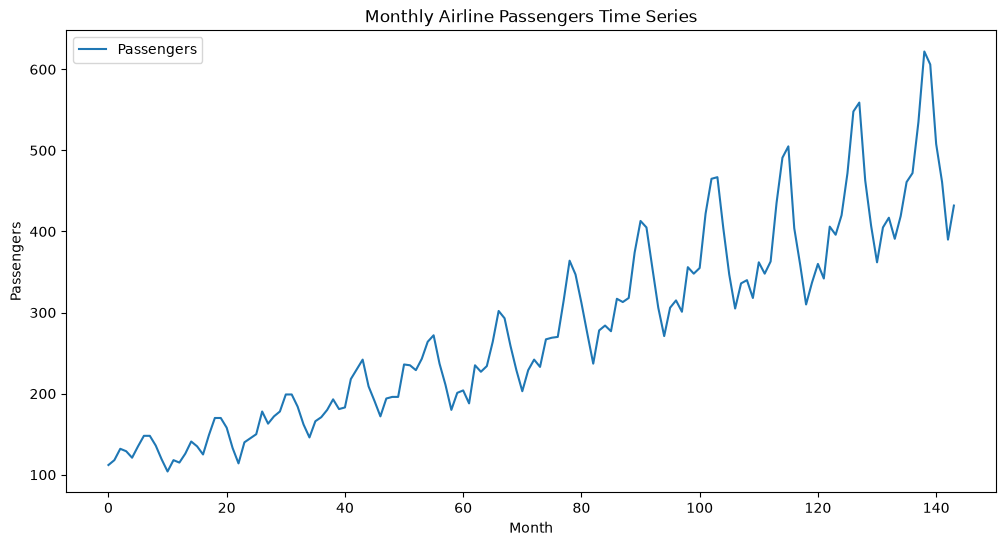

In [32]:
#plot time series
plt.figure(figsize=(12,6))
plt.plot( df['Passengers'], label='Passengers')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.title('Monthly Airline Passengers Time Series')
plt.legend()
plt.show()  

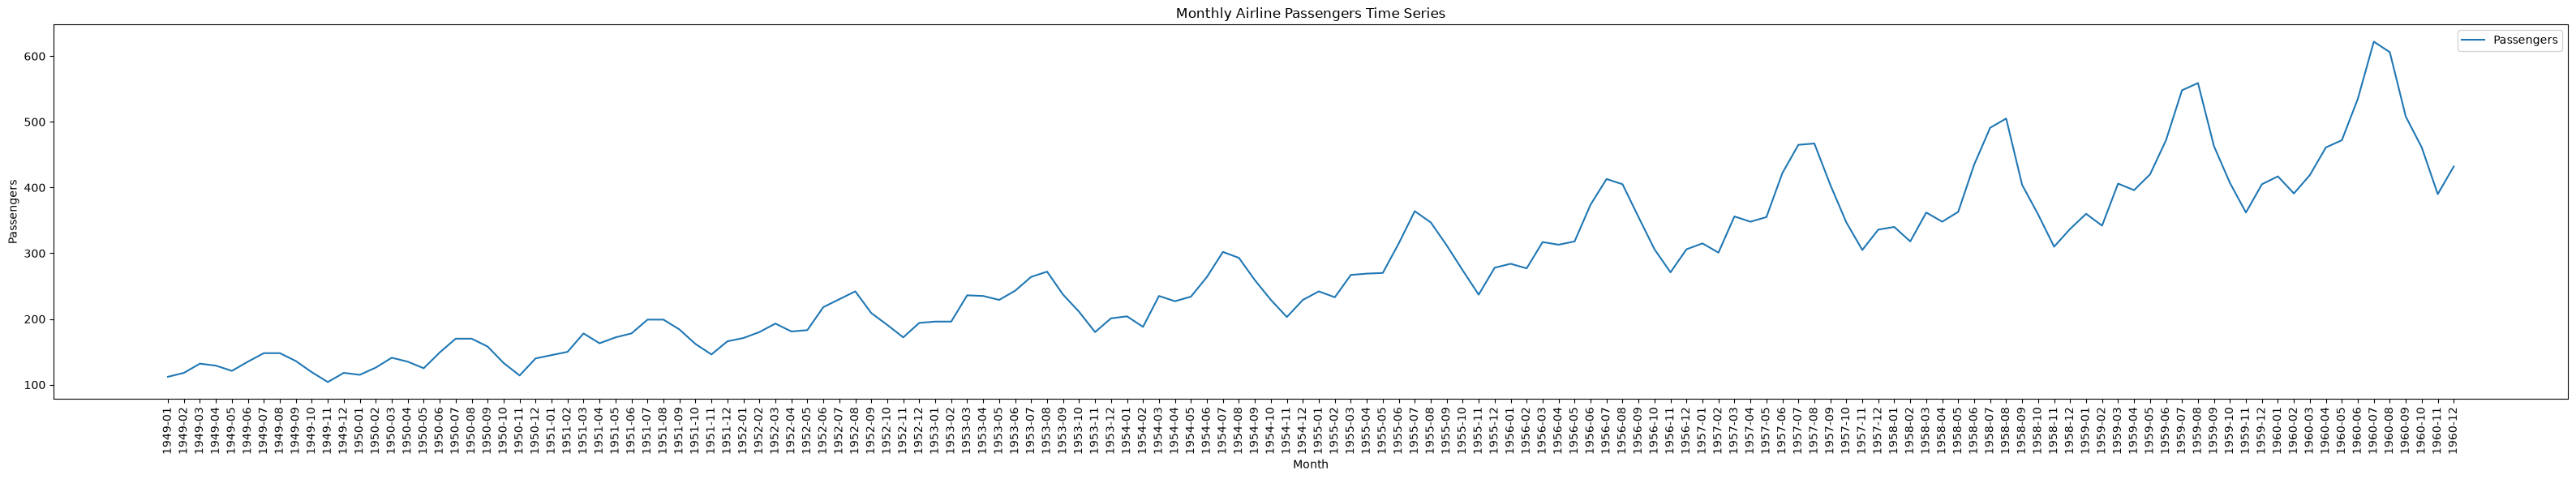

In [47]:
#one time plot Passengers and moth 
plt.figure(figsize=(40,6))
plt.plot( df['Month'], df['Passengers'], label='Passengers')
plt.title('Monthly Airline Passengers Time Series')
plt.xlabel('Month')
plt.xticks(rotation="vertical")
plt.ylabel('Passengers')
plt.legend()
plt.show()

In [ ]:
# check stationarity of the time series
result = adfuller(df['Passengers'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: 0.815369
p-value: 0.991880


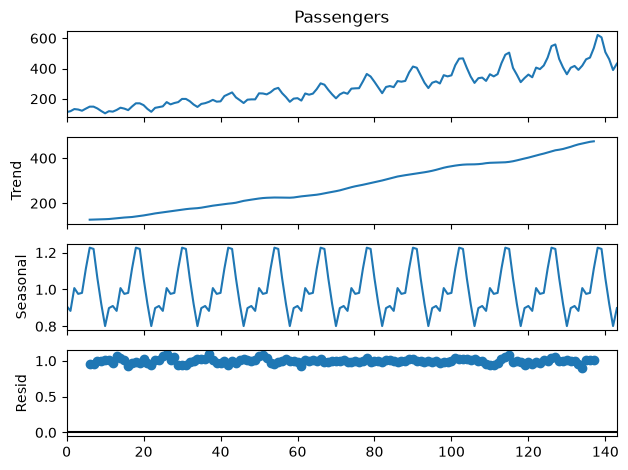

In [50]:
# seasonal decomposition
decomposition = seasonal_decompose(
    df['Passengers'],
    model='multiplicative',
    period=12
)
decomposition.plot()
plt.show()



In [59]:
#train test split
train= df.iloc[:-12]
test=df.iloc[-12:]

In [60]:
train.shape, test.shape

((132, 2), (12, 2))

In [61]:
# create  the  .pkl file for train and test data
train.to_pickle('../models/train_data.pkl')
test.to_pickle('../models/test_data.pkl')